#Sistema de Prevenção de Inundações

## 1. Instalação e Importação de Bibliotecas

In [56]:
# 1. INSTALAR BIBLIOTECAS (se necessário)
!pip install xgboost -q
!pip install plotly -q

In [57]:
# 2. IMPORTAR BIBLIOTECAS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print(" Bibliotecas importadas com sucesso!")


 Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

In [58]:
# 3. UPLOAD DO DATASET
from google.colab import files
import io

print("\n FAÇA UPLOAD DO SEU ARQUIVO dataset.csv")
uploaded = files.upload()


 FAÇA UPLOAD DO SEU ARQUIVO dataset.csv


Saving dataset_realista.csv to dataset_realista (1).csv


In [100]:
# Carregar dataset
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f" Dataset '{filename}' carregado com sucesso!")
print(f"Dimensões do dataset: {df.shape}")
print(f"\nPrimeiras linhas:")
display(df.head())

 Dataset 'dataset_realista (1).csv' carregado com sucesso!
Dimensões do dataset: (500, 11)

Primeiras linhas:


,provincia,latitude,longitude,ano,mes,precipitacao_mm,temperatura_C,humidade_percent,vento_kmh,rad_solar_Wm2,flood
0,Luanda,-8.789329,13.275174,2024,4,155.359826,30.694854,95.000000,15.069739,160.583228,1
1,Cunene,-16.262744,15.753658,2023,6,0.000000,28.896548,54.377125,7.948676,257.856183,0
2,Luanda,-8.929802,13.147770,2024,12,205.308285,25.411325,95.000000,12.443690,118.571018,1
3,Benguela,-12.538430,13.345936,2024,3,200.983658,25.776341,89.619622,15.290180,118.987080,1
4,Huíla,-14.896114,13.737033,2023,6,75.590276,26.650775,73.961572,10.795585,175.241812,0


## 3. Exploração e Análise de Dados (EAD)

In [60]:
# EXPLORAÇÃO E ANÁLISE DE DADOS (EAD) INTERATIVA
print(" EXPLORAÇÃO COMPLETA DO DATASET")
print(f" Dimensões do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas")

# Carregar o dataset gerado
df = pd.read_csv('dataset_realista.csv')

 EXPLORAÇÃO COMPLETA DO DATASET
 Dimensões do dataset: 500 linhas × 11 colunas


In [61]:
# Análise da variável target
print(f"\n ANÁLISE DA VARIÁVEL TARGET 'flood':")
target_analysis = df['flood'].value_counts()
target_percentage = df['flood'].value_counts(normalize=True) * 100
print(f"   Flood = 0: {target_analysis[0]} amostras ({target_percentage[0]:.1f}%)")
print(f"   Flood = 1: {target_analysis[1]} amostras ({target_percentage[1]:.1f}%)")


 ANÁLISE DA VARIÁVEL TARGET 'flood':
   Flood = 0: 157 amostras (31.4%)
   Flood = 1: 343 amostras (68.6%)


In [62]:
# Estatísticas descritivas detalhadas
print(f"\n ESTATÍSTICAS DESCRITIVAS DETALHADAS:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())


 ESTATÍSTICAS DESCRITIVAS DETALHADAS:
         latitude   longitude          ano         mes  precipitacao_mm  \
count  500.000000  500.000000   500.000000  500.000000       500.000000   
mean   -11.252103   14.897411  2024.048000    6.504000       128.892655   
std      3.504012    2.290580     0.801862    3.579331        76.502605   
min    -16.523340   11.957970  2023.000000    1.000000         0.000000   
25%    -12.936201   13.331725  2023.000000    3.000000        71.651379   
50%    -12.353407   14.131205  2024.000000    7.000000       118.776051   
75%     -7.800944   15.769616  2025.000000   10.000000       179.850378   
max     -5.340206   20.298526  2025.000000   12.000000       406.703544   

       temperatura_C  humidade_percent   vento_kmh  rad_solar_Wm2       flood  
count     500.000000        500.000000  500.000000     500.000000  500.000000  
mean       27.425868         82.021254   12.051125     187.456554    0.686000  
std         3.029728         12.775250    3.7

In [63]:
# Análise de valores ausentes
print(f"\n ANÁLISE DE VALORES AUSENTES:")
missing_data = df.isnull().sum()
if missing_data.sum() == 0:
    print("  Nenhum valor ausente encontrado")
else:
    for col, missing in missing_data.items():
        if missing > 0:
            print(f"   {col}: {missing} valores ausentes ({missing/len(df)*100:.1f}%)")


 ANÁLISE DE VALORES AUSENTES:
  Nenhum valor ausente encontrado


In [64]:
# Análise de outliers usando IQR
print(f"\n DETECÇÃO DE OUTLIERS (Método IQR):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"   {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")


 DETECÇÃO DE OUTLIERS (Método IQR):
   latitude: 0 outliers (0.0%)
   longitude: 63 outliers (12.6%)
   ano: 0 outliers (0.0%)
   mes: 0 outliers (0.0%)
   precipitacao_mm: 4 outliers (0.8%)
   temperatura_C: 5 outliers (1.0%)
   humidade_percent: 0 outliers (0.0%)
   vento_kmh: 0 outliers (0.0%)
   rad_solar_Wm2: 0 outliers (0.0%)
   flood: 0 outliers (0.0%)


In [65]:
# Análise por província
print(f"\n ANÁLISE POR PROVÍNCIA:")
print(f"   Número de províncias: {df['provincia'].nunique()}")
provincia_stats = df.groupby('provincia').agg({
    'flood': ['count', 'mean'],
    'precipitacao_mm': 'mean',
    'temperatura_C': 'mean'
}).round(3)

for prov in df['provincia'].unique():
    prov_data = df[df['provincia'] == prov]
    flood_rate = prov_data['flood'].mean() * 100
    avg_precip = prov_data['precipitacao_mm'].mean()
    print(f"   {prov}: {len(prov_data)} amostras, {flood_rate:.1f}% flood, {avg_precip:.1f}mm precip")


 ANÁLISE POR PROVÍNCIA:
   Número de províncias: 8
   Luanda: 58 amostras, 55.2% flood, 86.0mm precip
   Cunene: 62 amostras, 51.6% flood, 98.7mm precip
   Benguela: 62 amostras, 61.3% flood, 122.7mm precip
   Huíla: 60 amostras, 63.3% flood, 129.5mm precip
   Cabinda: 73 amostras, 80.8% flood, 164.3mm precip
   Huambo: 67 amostras, 80.6% flood, 158.7mm precip
   Moxico: 63 amostras, 61.9% flood, 109.3mm precip
   Uíge: 55 amostras, 92.7% flood, 153.7mm precip


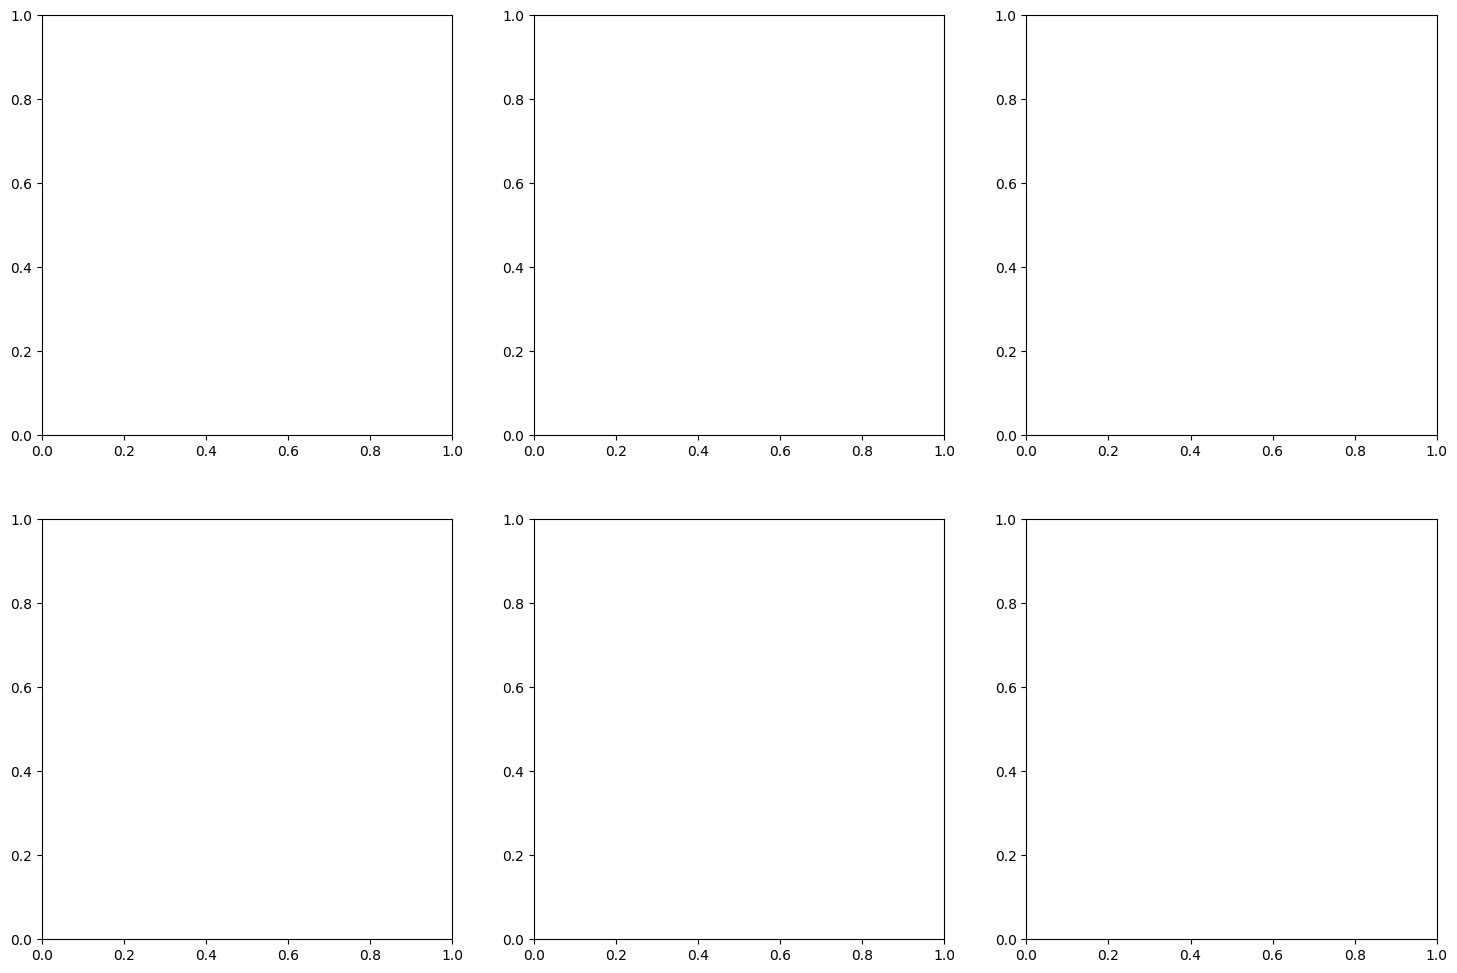

In [66]:
# Visualizações
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

In [67]:
# Gráfico 1: Distribuição do Target
fig1 = px.pie(df, names='flood', title='Distribuição da Variável Target (Flood)',
              color='flood', color_discrete_map={0:'lightblue', 1:'salmon'})
fig1.update_traces(textinfo='percent+label')
fig1.show()

In [68]:
# Gráfico 2: Distribuição por Província
fig2 = px.sunburst(df, path=['provincia', 'flood'],
                   title='Distribuição de Flood por Província',
                   color='flood', color_continuous_scale='Blues')
fig2.show()

In [69]:
# Gráfico 3: Precipitação vs Flood
fig3 = px.box(df, x='flood', y='precipitacao_mm',
              title='Precipitação vs Ocorrência de Flood',
              color='flood', color_discrete_map={0:'lightblue', 1:'salmon'})
fig3.update_layout(xaxis_title='Flood', yaxis_title='Precipitação (mm)')
fig3.show()

In [70]:
# Gráfico 4: Mapa Interativo de Floods
fig4 = px.scatter_mapbox(df, lat="latitude", lon="longitude",
                         color="flood", size="precipitacao_mm",
                         hover_name="provincia",
                         hover_data=["temperatura_C", "humidade_percent"],
                         title="Mapa de Ocorrências de Flood em Angola",
                         color_continuous_scale=px.colors.diverging.RdYlBu_r,
                         zoom=5, height=500)
fig4.update_layout(mapbox_style="open-street-map")
fig4.show()

In [71]:
# Gráfico 5: Correlação Interativa
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

fig5 = px.imshow(corr_matrix,
                 title='Matriz de Correlação Interativa',
                 color_continuous_scale='RdBu_r',
                 aspect="auto")
fig5.update_layout(height=600)
fig5.show()

In [72]:
# Gráfico 6: Distribuição Temporal
fig6 = px.histogram(df, x='mes', color='flood', barmode='group',
                   title='Distribuição de Flood por Mês',
                   color_discrete_map={0:'lightblue', 1:'salmon'})
fig6.update_layout(xaxis_title='Mês', yaxis_title='Contagem')
fig6.show()


 MATRIZ DE CORRELAÇÃO


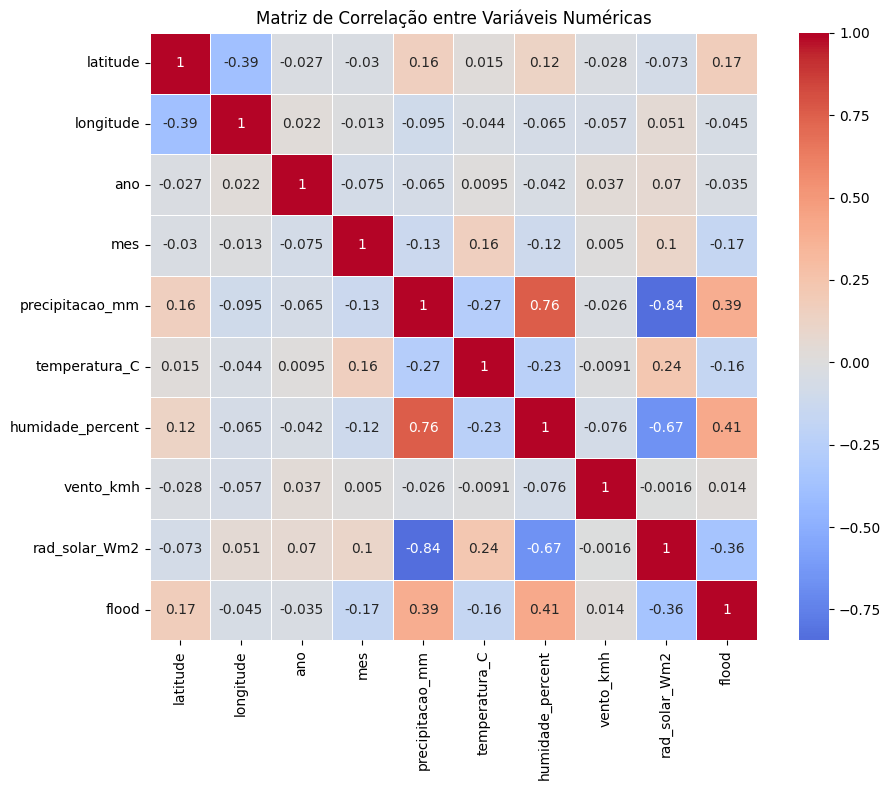

In [73]:
# ANÁLISE DE CORRELAÇÃO
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    print("\n MATRIZ DE CORRELAÇÃO")
    correlation_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Matriz de Correlação entre Variáveis Numéricas')
    plt.tight_layout()
    plt.show()

## 4. Engenharia de Recursos

In [74]:
# ENGENHARIA DE RECURSOS
print(" ENGENHARIA DE RECURSOS")

# Criar cópia para processamento
df_processed = df.copy()

# Identificar automaticamente tipos de colunas
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_processed.select_dtypes(include=[np.number]).drop('flood', axis=1, errors='ignore').columns.tolist()

print(f" Colunas categóricas identificadas: {categorical_cols}")
print(f" Colunas numéricas identificadas: {numeric_cols}")


 ENGENHARIA DE RECURSOS
 Colunas categóricas identificadas: ['provincia']
 Colunas numéricas identificadas: ['latitude', 'longitude', 'ano', 'mes', 'precipitacao_mm', 'temperatura_C', 'humidade_percent', 'vento_kmh', 'rad_solar_Wm2']


In [75]:
# Criar cópia para engineering
df_engineered = df.copy()

print(" CRIANDO NOVAS FEATURES...")

# 1. Features de Interação entre Variáveis Meteorológicas
df_engineered['precip_temp_interaction'] = df_engineered['precipitacao_mm'] * df_engineered['temperatura_C']
df_engineered['precip_humidity_interaction'] = df_engineered['precipitacao_mm'] * df_engineered['humidade_percent']
df_engineered['temp_humidity_interaction'] = df_engineered['temperatura_C'] * df_engineered['humidade_percent']
print(" Features de interação criadas")

 CRIANDO NOVAS FEATURES...
 Features de interação criadas


In [76]:
# 2. Features de Sazonalidade
df_engineered['estacao_chuvosa'] = df_engineered['mes'].apply(lambda x: 1 if x in [11, 12, 1, 2, 3] else 0)
df_engineered['trimestre'] = (df_engineered['mes'] - 1) // 3 + 1
print(" Features sazonais criadas")

 Features sazonais criadas


In [78]:
# 3. Features de Risco Composto
df_engineered['risco_precipitacao'] = df_engineered['precipitacao_mm'].apply(
    lambda x: 0 if x < 100 else (1 if x < 180 else 2)
)
df_engineered['risco_humidade'] = df_engineered['humidade_percent'].apply(
    lambda x: 0 if x < 70 else (1 if x < 85 else 2)
)
df_engineered['score_risco_total'] = (
    df_engineered['risco_precipitacao'] +
    df_engineered['risco_humidade'] +
    df_engineered['estacao_chuvosa']
)
print(" Features de risco compostas criadas")

 Features de risco compostas criadas


In [79]:
# 4. Features de Agregação por Província
provincia_stats = df_engineered.groupby('provincia').agg({
    'precipitacao_mm': ['mean', 'std'],
    'temperatura_C': 'mean',
    'flood': 'mean'
}).round(3)

provincia_stats.columns = ['precip_mean_prov', 'precip_std_prov', 'temp_mean_prov', 'flood_rate_prov']
df_engineered = df_engineered.merge(provincia_stats, left_on='provincia', right_index=True, how='left')

In [80]:
# 5. Features de Diferença em Relação à Média da Província
df_engineered['precip_vs_prov_mean'] = df_engineered['precipitacao_mm'] - df_engineered['precip_mean_prov']
df_engineered['temp_vs_prov_mean'] = df_engineered['temperatura_C'] - df_engineered['temp_mean_prov']
print(" Features de agregação por província criadas")

 Features de agregação por província criadas


In [81]:
# 6. Features Polinomiais
df_engineered['precipitacao_quadratica'] = df_engineered['precipitacao_mm'] ** 2
df_engineered['temperatura_quadratica'] = df_engineered['temperatura_C'] ** 2
print(" Features polinomiais criadas")

print(f" Total de features criadas: {len(df_engineered.columns) - len(df.columns)}")
print(f" Shape após engenharia de features: {df_engineered.shape}")


 Features polinomiais criadas
 Total de features criadas: 16
 Shape após engenharia de features: (500, 27)


In [83]:
# Gráfico 1: Análise de Correlação com Features Engenheiradas
numeric_cols_engineered = df_engineered.select_dtypes(include=[np.number]).columns
corr_matrix = df_engineered[numeric_cols_engineered].corr()

fig2 = px.imshow(corr_matrix,
                 title='Matriz de Correlação com Features Engenheiradas',
                 color_continuous_scale='RdBu_r',
                 aspect="auto",
                 height=800)
fig2.show()

In [84]:
# Gráfico 2: Distribuição das Novas Features
fig3 = make_subplots(rows=2, cols=2,
                    subplot_titles=['Score de Risco Total', 'Interação Precip-Temp',
                                  'Precipitação vs Média Provincial', 'Risco de Precipitação'])

fig3.add_trace(go.Histogram(x=df_engineered['score_risco_total'], name='Score Risco'), row=1, col=1)
fig3.add_trace(go.Histogram(x=df_engineered['precip_temp_interaction'], name='Precip-Temp'), row=1, col=2)
fig3.add_trace(go.Histogram(x=df_engineered['precip_vs_prov_mean'], name='Precip vs Média'), row=2, col=1)
fig3.add_trace(go.Histogram(x=df_engineered['risco_precipitacao'], name='Risco Precip'), row=2, col=2)

fig3.update_layout(height=600, title_text="Distribuição das Novas Features")
fig3.show()

In [85]:
# Gráfico 3: Mapa Interativo com Novas Features
fig4 = px.scatter_mapbox(df_engineered, lat="latitude", lon="longitude",
                         color="score_risco_total", size="precipitacao_mm",
                         hover_name="provincia",
                         hover_data=["score_risco_total", "precipitacao_mm", "flood"],
                         title="Mapa de Risco de Flood em Angola",
                         color_continuous_scale="Viridis",
                         zoom=5, height=500)
fig4.update_layout(mapbox_style="open-street-map")
fig4.show()

In [87]:
# Gráfico 4: Relação entre Novas Features e Target
fig5 = px.box(df_engineered, x='flood', y='score_risco_total',
              title='Relação entre Score de Risco e Ocorrência de Flood',
              color='flood', color_discrete_map={0:'lightblue', 1:'salmon'})
fig5.show()

## 5. Pré-processamento e Divisão dos Dados

In [88]:
# PRÉ-PROCESSAMENTO DOS DADOS
print(" PRÉ-PROCESSAMENTO DOS DADOS")

# Criar cópia para processamento
df_processed = df_engineered.copy()

# Codificar variáveis categóricas
label_encoders = {}
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"Codificada: {col} → {len(le.classes_)} categorias")

 PRÉ-PROCESSAMENTO DOS DADOS
Codificada: provincia → 8 categorias


In [89]:
# Tratamento de valores ausentes
imputer = SimpleImputer(strategy='median')
numeric_cols = df_processed.select_dtypes(include=[np.number]).drop('flood', axis=1, errors='ignore').columns.tolist()

if len(numeric_cols) > 0:
    df_processed[numeric_cols] = imputer.fit_transform(df_processed[numeric_cols])
    print(" Valores ausentes tratados")

# Definir features e target
X = df_processed.drop('flood', axis=1)
y = df_processed['flood']

print(f" Shape final do dataset: {X.shape}")

 Valores ausentes tratados
 Shape final do dataset: (500, 26)


In [90]:
# DIVISÃO DOS DADOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n DIVISÃO DOS DADOS:")
print(f"   Treino: {X_train.shape[0]} amostras")
print(f"   Teste:  {X_test.shape[0]} amostras")
print(f"   Features: {X_train.shape[1]} variáveis")
print(f"   Distribuição no treino: {dict(y_train.value_counts(normalize=True).round(2))}")


 DIVISÃO DOS DADOS:
   Treino: 400 amostras
   Teste:  100 amostras
   Features: 26 variáveis
   Distribuição no treino: {1: np.float64(0.68), 0: np.float64(0.32)}


## 6. Modelagem com Otimização

In [91]:
#  MODELAGEM COM OTIMIZAÇÃO
print(" TREINAMENTO E OTIMIZAÇÃO DE MODELOS")

# Configurar pipelines
pipelines = {
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
    ]),
    "Regressão Logística": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ])
}

 TREINAMENTO E OTIMIZAÇÃO DE MODELOS


In [92]:
# Hiperparâmetros para otimização
param_grids = {
    "Random Forest": {
        'model__n_estimators': [100, 150],
        'model__max_depth': [10, None],
        'model__min_samples_split': [2, 5]
    },
    "XGBoost": {
        'model__n_estimators': [100, 150],
        'model__max_depth': [3, 6],
        'model__learning_rate': [0.01, 0.1]
    },
    "Regressão Logística": {
        'model__C': [0.1, 1, 10],
        'model__solver': ['liblinear', 'lbfgs']
    }
}

## 7. Treinamento e Avaliação dos Modelos

In [93]:
# Treinar e avaliar modelos
results = []
best_models = {}
y_pred_probas = {}

print(" Iniciando otimização dos modelos...")

for name, pipeline in pipelines.items():
    print(f"\n Otimizando {name}...")

    try:
        grid_search = GridSearchCV(
            pipeline, param_grids[name],
            cv=StratifiedKFold(n_splits=5),
            scoring='f1',
            n_jobs=-1,
            verbose=0
        )

        grid_search.fit(X_train, y_train)
        best_models[name] = grid_search.best_estimator_

        # Previsões
        y_pred = best_models[name].predict(X_test)
        y_pred_proba = best_models[name].predict_proba(X_test)[:, 1]
        y_pred_probas[name] = y_pred_proba

        # Métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)

        results.append([name, acc, prec, rec, f1, auc])

        print(f"   Melhores parâmetros: {grid_search.best_params_}")
        print(f"   F1-Score: {f1:.4f}, AUC: {auc:.4f}")

    except Exception as e:
        print(f"   Erro em {name}: {e}")

 Iniciando otimização dos modelos...

 Otimizando Random Forest...
   Melhores parâmetros: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 150}
   F1-Score: 0.8219, AUC: 0.6919

 Otimizando XGBoost...
   Melhores parâmetros: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 150}
   F1-Score: 0.8356, AUC: 0.7137

 Otimizando Regressão Logística...
   Melhores parâmetros: {'model__C': 0.1, 'model__solver': 'lbfgs'}
   F1-Score: 0.8028, AUC: 0.7518


In [94]:
# RESULTADOS E COMPARAÇÃO
print(" RESULTADOS FINAIS DOS MODELOS")

if results:
    results_df = pd.DataFrame(results, columns=['Modelo', 'Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC'])
    results_df = results_df.round(4)

    # Display interativo dos resultados
    print(" Resultados detalhados:")
    display(results_df.style.background_gradient(cmap='Blues').format({
        'Acurácia': '{:.3f}',
        'Precisão': '{:.3f}',
        'Recall': '{:.3f}',
        'F1-Score': '{:.3f}',
        'AUC-ROC': '{:.3f}'
    }))

    # Identificar melhor modelo
    best_model_idx = results_df['F1-Score'].idxmax()
    best_model_name = results_df.loc[best_model_idx, 'Modelo']
    best_model = best_models[best_model_name]

    print(f"\n MELHOR MODELO: {best_model_name}")
    print(f"   F1-Score: {results_df.loc[best_model_idx, 'F1-Score']:.4f}")
    print(f"   AUC-ROC: {results_df.loc[best_model_idx, 'AUC-ROC']:.4f}")
    print(f"   Acurácia: {results_df.loc[best_model_idx, 'Acurácia']:.4f}")

 RESULTADOS FINAIS DOS MODELOS
 Resultados detalhados:


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
0,Random Forest,0.740,0.779,0.870,0.822,0.692
1,XGBoost,0.760,0.792,0.884,0.836,0.714
2,Regressão Logística,0.720,0.781,0.826,0.803,0.752



 MELHOR MODELO: XGBoost
   F1-Score: 0.8356
   AUC-ROC: 0.7137
   Acurácia: 0.7600


In [96]:
#  VISUALIZAÇÕES INTERATIVAS DOS RESULTADOS
print(" VISUALIZAÇÕES INTERATIVAS DOS RESULTADOS")

# Gráfico 6: Comparação de Métricas
metrics_df = results_df.melt(id_vars=['Modelo'],
                            value_vars=['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC'],
                            var_name='Métrica', value_name='Valor')

fig6 = px.bar(metrics_df, x='Modelo', y='Valor', color='Métrica',
             title='Comparação de Desempenho dos Modelos',
             barmode='group', text='Valor',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig6.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig6.update_layout(height=500, xaxis_tickangle=-45)
fig6.show()

# Gráfico 7: Curvas ROC Interativas
fig7 = go.Figure()

for name, y_pred_proba in y_pred_probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    fig7.add_trace(go.Scatter(
        x=fpr, y=tpr,
        name=f'{name} (AUC = {auc_score:.3f})',
        mode='lines',
        line=dict(width=3)
    ))

fig7.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    name='Classificador Aleatório',
    line=dict(dash='dash', color='gray')
))

fig7.update_layout(
    title='Curvas ROC - Comparação de Modelos',
    xaxis_title='Taxa de Falsos Positivos',
    yaxis_title='Taxa de Verdadeiros Positivos',
    height=500
)
fig7.show()

# Gráfico 8: Matriz de Confusão do Melhor Modelo
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig8 = px.imshow(cm,
                text_auto=True,
                title=f'Matriz de Confusão - {best_model_name}',
                color_continuous_scale='Blues',
                labels=dict(x="Predito", y="Real", color="Contagem"))
fig8.update_xaxes(side="top", ticktext=['Não Flood', 'Flood'], tickvals=[0, 1])
fig8.update_yaxes(ticktext=['Não Flood', 'Flood'], tickvals=[0, 1])
fig8.show()

# Gráfico 9: Importância das Features (se disponível)
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.named_steps['model'].feature_importances_
    }).sort_values('importance', ascending=True).tail(15)

    fig9 = px.bar(feature_importance,
                  x='importance', y='feature',
                  title='Top 15 Features Mais Importantes',
                  color='importance',
                  color_continuous_scale='Viridis',
                  text='importance')
    fig9.update_traces(texttemplate='%{text:.3f}', textposition='outside')
    fig9.update_layout(height=500, showlegend=False)
    fig9.show()

 VISUALIZAÇÕES INTERATIVAS DOS RESULTADOS


## 8. Relatório Final

In [99]:
import pandas as pd
import pickle
from datetime import datetime

# Generate a timestamp for filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save the results DataFrame to a CSV file
results_filename = f"resultados_modelos_{timestamp}.csv"
results_df.to_csv(results_filename, index=False)
print(f"Resultados salvos em: {results_filename}")

# Save the best model to a pickle file
model_filename = f"melhor_modelo_inundacoes_{timestamp}.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"Melhor modelo salvo em: {model_filename}")

Resultados salvos em: resultados_modelos_20251105_221147.csv
Melhor modelo salvo em: melhor_modelo_inundacoes_20251105_221147.pkl


In [98]:
print(" RELATÓRIO FINAL COMPLETO")

if results:
    print(f" MELHOR MODELO: {best_model_name}")
    print(f" PERFORMANCE:")
    print(f"   • F1-Score: {results_df.loc[best_model_idx, 'F1-Score']:.4f}")
    print(f"   • AUC-ROC: {results_df.loc[best_model_idx, 'AUC-ROC']:.4f}")
    print(f"   • Acurácia: {results_df.loc[best_model_idx, 'Acurácia']:.4f}")
    print(f"   • Precisão: {results_df.loc[best_model_idx, 'Precisão']:.4f}")
    print(f"   • Recall: {results_df.loc[best_model_idx, 'Recall']:.4f}")

    print(f"\n ENGENHARIA DE FEATURES:")
    print(f"   • Features originais: {len(df.columns)}")
    print(f"   • Features após engineering: {len(df_engineered.columns)}")
    print(f"   • Novas features criadas: {len(df_engineered.columns) - len(df.columns)}")

    print(f"\n EAD REALIZADO:")
    print(f"   • Análise de distribuição do target")
    print(f"   • Detecção de outliers")
    print(f"   • Análise por província")
    print(f"   • Matriz de correlação completa")
    print(f"   • Visualizações interativas")

else:
    print(" Nenhum modelo foi treinado com sucesso.")

print(" PROCESSO CONCLUÍDO COM SUCESSO!")

 RELATÓRIO FINAL COMPLETO
 MELHOR MODELO: XGBoost
 PERFORMANCE:
   • F1-Score: 0.8356
   • AUC-ROC: 0.7137
   • Acurácia: 0.7600
   • Precisão: 0.7922
   • Recall: 0.8841

 ENGENHARIA DE FEATURES:
   • Features originais: 11
   • Features após engineering: 27
   • Novas features criadas: 16

 EAD REALIZADO:
   • Análise de distribuição do target
   • Detecção de outliers
   • Análise por província
   • Matriz de correlação completa
   • Visualizações interativas
 PROCESSO CONCLUÍDO COM SUCESSO!
